In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from scipy.sparse import hstack
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

In [14]:
df=pd.read_csv('fake_reviews_cleaned.csv')
df

,category,rating,label,clean_text
0,Home_&_Kitchen,5.0,0,love well made sturdy comfortable love pretty
1,Home_&_Kitchen,5.0,0,love great upgrade original mine couple year
2,Home_&_Kitchen,5.0,0,pillow saved back love look feel pillow
3,Home_&_Kitchen,1.0,0,missing information use great product price
4,Home_&_Kitchen,5.0,0,nice set good quality set two month not
...,...,...,...,...
40415,Clothing_Shoes_&_Jewelry,4.0,1,read review saying bra ran small ordered two b...
40416,Clothing_Shoes_&_Jewelry,5.0,0,not sure exactly would little large small size...
40417,Clothing_Shoes_&_Jewelry,2.0,1,wear hood wear hood wear jacket without hood s...
40418,Clothing_Shoes_&_Jewelry,1.0,0,liked nothing dress reason gave star ordered s...


In [15]:
df = df.dropna(subset=['clean_text', 'label']).reset_index(drop=True)
df.isnull().sum()

category      0
rating        0
label         0
clean_text    0
dtype: int64

In [16]:
category_encoder = LabelEncoder()
df['category_encoded'] = category_encoder.fit_transform(df['category'])
df = df.drop(columns=['category'])  # Hapus kolom asli jika tidak diperlukan

In [17]:
X_text = df['clean_text']
X_numeric = df[['category_encoded', 'rating']]  # 2 fitur numerik
y = df['label']

In [18]:
X_numeric

,category_encoded,rating
0,3,5.0
1,3,5.0
2,3,5.0
3,3,1.0
4,3,5.0
...,...,...
40414,1,4.0
40415,1,5.0
40416,1,2.0
40417,1,1.0


In [19]:
# ================================================================
# 1. TRAIN–VAL–TEST SPLIT
# ================================================================
# Split 1 — 75% train, 25% temp
X_text_temp, X_text_train, X_num_temp, X_num_train, y_temp, y_train = train_test_split(
    X_text, X_numeric, y, test_size=0.75, random_state=42, stratify=y
)

# Split 2 — temp: 60% val, 40% test
X_text_val, X_text_test, X_num_val, X_num_test, y_val, y_test = train_test_split(
    X_text_temp, X_num_temp, y_temp, test_size=0.4, random_state=42, stratify=y_temp
)
print(f"Train: {len(X_text_train)} samples ({len(X_text_train)/len(df)*100:.1f}%)")
print(f"Val: {len(X_text_val)} samples ({len(X_text_val)/len(df)*100:.1f}%)")  
print(f"Test: {len(X_text_test)} samples ({len(X_text_test)/len(df)*100:.1f}%)")

Train: 30315 samples (75.0%)
Val: 6062 samples (15.0%)
Test: 4042 samples (10.0%)


In [20]:
# ================================================================
# 2. TF-IDF VECTORIZATION
# ================================================================
# TF-IDF FIT only in train, TRANSFORM in val & test
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_text_train_tfidf = vectorizer.fit_transform(X_text_train)  
X_text_val_tfidf = vectorizer.transform(X_text_val)          
X_text_test_tfidf = vectorizer.transform(X_text_test)

# Combine TF-IDF + numeric
X_train_final = hstack([X_text_train_tfidf, X_num_train])
X_val_final = hstack([X_text_val_tfidf, X_num_val])
X_test_final = hstack([X_text_test_tfidf, X_num_test])

In [21]:
# ================================================================
# 3. TRAINING SVM MODEL
# ================================================================
svm_model = SVC(kernel='linear', random_state=42, probability=True)
svm_model.fit(X_train_final, y_train)

# ================================================================
# 4. VALIDATION EVALUATION
# ================================================================
y_val_pred = svm_model.predict(X_val_final)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.8590


In [22]:
# ================================================================
# 5. TEST SET EVALUATION
# ================================================================
y_test_pred = svm_model.predict(X_test_final)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

precision_svm = precision_score(y_test, y_test_pred, average='weighted')
recall_svm    = recall_score(y_test, y_test_pred, average='weighted')
f1_svm        = f1_score(y_test, y_test_pred, average='weighted')

print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1 Score:  {f1_svm:.4f}")

Test Accuracy: 0.8511

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      2021
           1       0.85      0.86      0.85      2021

    accuracy                           0.85      4042
   macro avg       0.85      0.85      0.85      4042
weighted avg       0.85      0.85      0.85      4042

Precision: 0.8511
Recall:    0.8511
F1 Score:  0.8511


[[1707  314]
 [ 288 1733]]


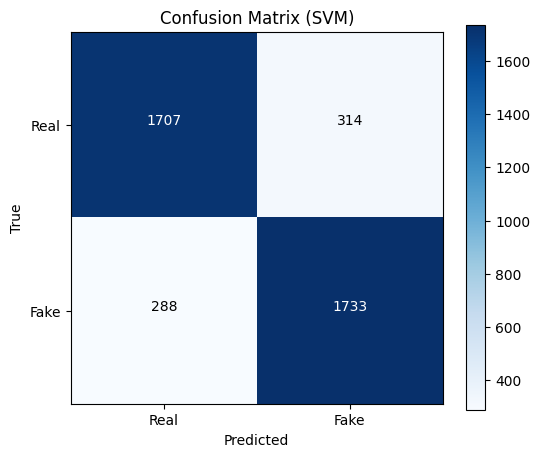

In [23]:
# ================================================================
# 6. CONFUSION MATRIX
# ================================================================
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (SVM)")
plt.colorbar()

plt.xticks([0, 1], ["Real", "Fake"])
plt.yticks([0, 1], ["Real", "Fake"])

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

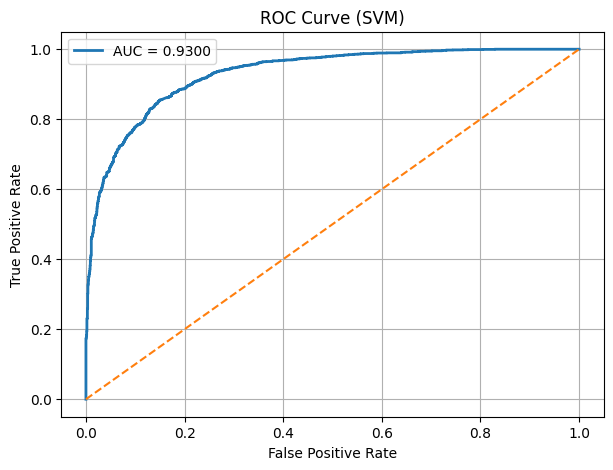

In [24]:
# ================================================================
# 7. ROC–AUC CURVE
# ================================================================
y_probs = svm_model.predict_proba(X_test_final)
fpr, tpr, _ = roc_curve(y_test, y_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM)")
plt.legend(loc="lower right")
plt.legend()
plt.grid(True)
plt.show()